<a href="https://colab.research.google.com/github/ElianaHeitner/CNN-and-MLP-project/blob/main/task_4_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 4- Augmentation


In [1]:
# Imports and configuration
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# Transforms with Data Augmentation for training
train_transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Transforms for testing (NO augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 Dataset
train_dataset_aug = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform_aug)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Create DataLoaders
batch_size = 128
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 47.7MB/s]


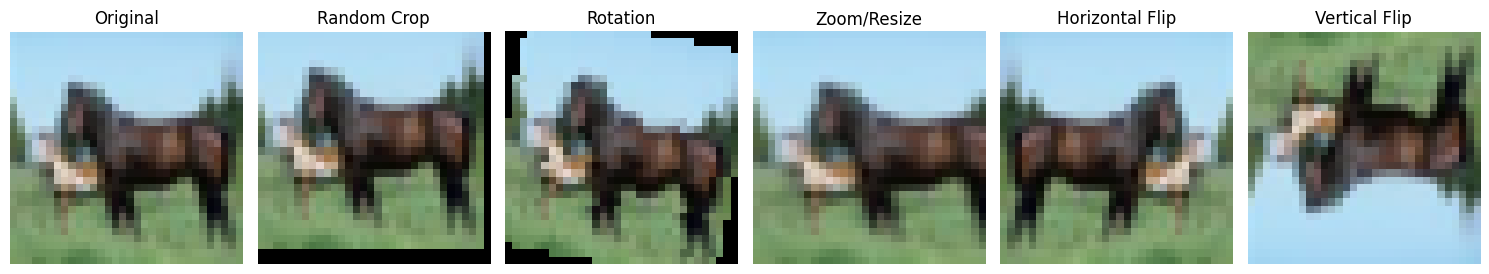

In [2]:
# Load raw images just for demonstrating the transformations in the report
raw_dataset = datasets.CIFAR10(root='./data', train=True, download=True)
img, label = raw_dataset[12] # Selecting a sample image (e.g., horse)

# Define individual transformations for visualization
transformations = {
    "Original": transforms.Lambda(lambda x: x),
    "Random Crop": transforms.RandomCrop(32, padding=4),
    "Rotation": transforms.RandomRotation(45),
    "Zoom/Resize": transforms.RandomResizedCrop(32, scale=(0.7, 1.0)),
    "Horizontal Flip": transforms.RandomHorizontalFlip(p=1.0),
    "Vertical Flip": transforms.RandomVerticalFlip(p=1.0)
}

# Plot the transformations
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, (name, transform) in zip(axes, transformations.items()):
    augmented_img = transform(img)
    ax.imshow(augmented_img)
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
# CNN architecture from Task 1
class InitialCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = torch.sigmoid(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = torch.sigmoid(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.sigmoid(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = torch.sigmoid(self.conv4(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize Network and optimizer
model = InitialCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [4]:
# Training function
def train(model, loader):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100 * correct / total

# Testing function
def test(model, loader):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100 * correct / total

# Main training loop
num_epochs = 15
print("Starting training with augmented data...")
for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader_aug)
    test_loss, test_acc = test(model, test_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

Starting training with augmented data...
Epoch 1/15 | Train Acc: 16.22% | Test Acc: 25.08%
Epoch 2/15 | Train Acc: 26.07% | Test Acc: 29.82%
Epoch 3/15 | Train Acc: 29.76% | Test Acc: 37.53%
Epoch 4/15 | Train Acc: 34.37% | Test Acc: 41.26%
Epoch 5/15 | Train Acc: 38.25% | Test Acc: 44.12%
Epoch 6/15 | Train Acc: 41.10% | Test Acc: 47.43%
Epoch 7/15 | Train Acc: 42.67% | Test Acc: 48.40%
Epoch 8/15 | Train Acc: 44.43% | Test Acc: 48.65%
Epoch 9/15 | Train Acc: 45.62% | Test Acc: 49.56%
Epoch 10/15 | Train Acc: 46.68% | Test Acc: 50.99%
Epoch 11/15 | Train Acc: 48.09% | Test Acc: 51.91%
Epoch 12/15 | Train Acc: 48.98% | Test Acc: 52.89%
Epoch 13/15 | Train Acc: 49.79% | Test Acc: 52.74%
Epoch 14/15 | Train Acc: 50.94% | Test Acc: 54.95%
Epoch 15/15 | Train Acc: 51.98% | Test Acc: 55.40%


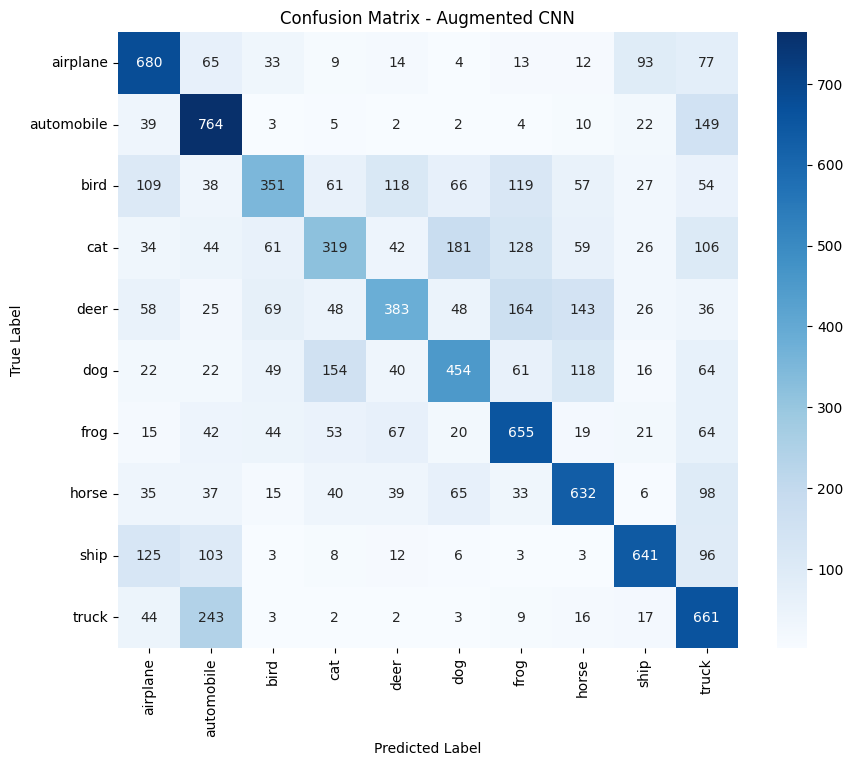

In [6]:
# Generate confusion matrix for the report
def plot_confusion_matrix(model, loader, classes):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - Augmented CNN')
    plt.show()

# CIFAR-10 class names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plot_confusion_matrix(model, test_loader, classes)

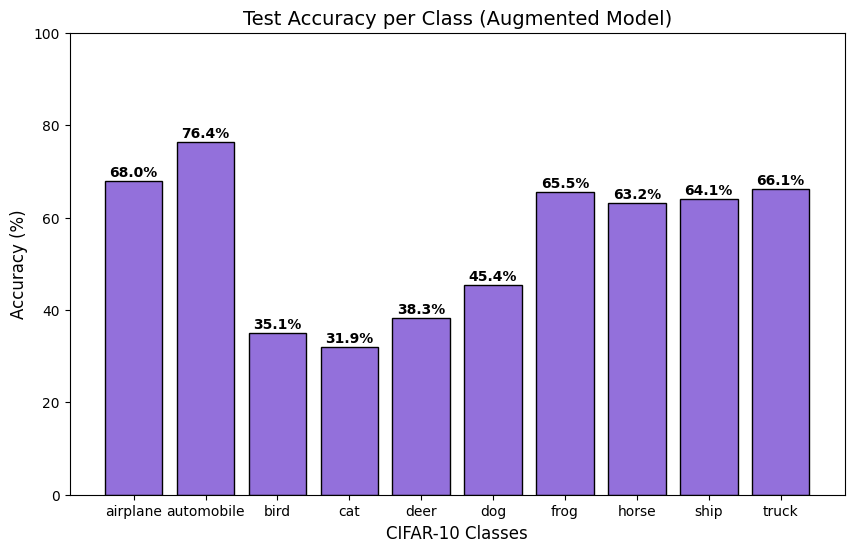

In [7]:
# 6. Extra Analysis: Class-wise Accuracy Bar Chart
def plot_class_accuracy(model, loader, classes):
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))
    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            c = (predicted == labels).squeeze()
            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    accuracies = [100 * class_correct[i] / class_total[i] for i in range(10)]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(classes, accuracies, color='mediumpurple', edgecolor='black')
    plt.xlabel('CIFAR-10 Classes', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.title('Test Accuracy per Class (Augmented Model)', fontsize=14)
    plt.ylim(0, 100)

    # Adding the percentages on top of each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', fontsize=10, fontweight='bold')

    plt.show()

plot_class_accuracy(model, test_loader, classes)